Saved parsed metrics to: training_curves/loss_and_magnitude_curves.csv
Saved figure to: training_curves/loss_and_magnitude_curves.pdf
Saved figure to: training_curves/loss_and_magnitude_curves.png


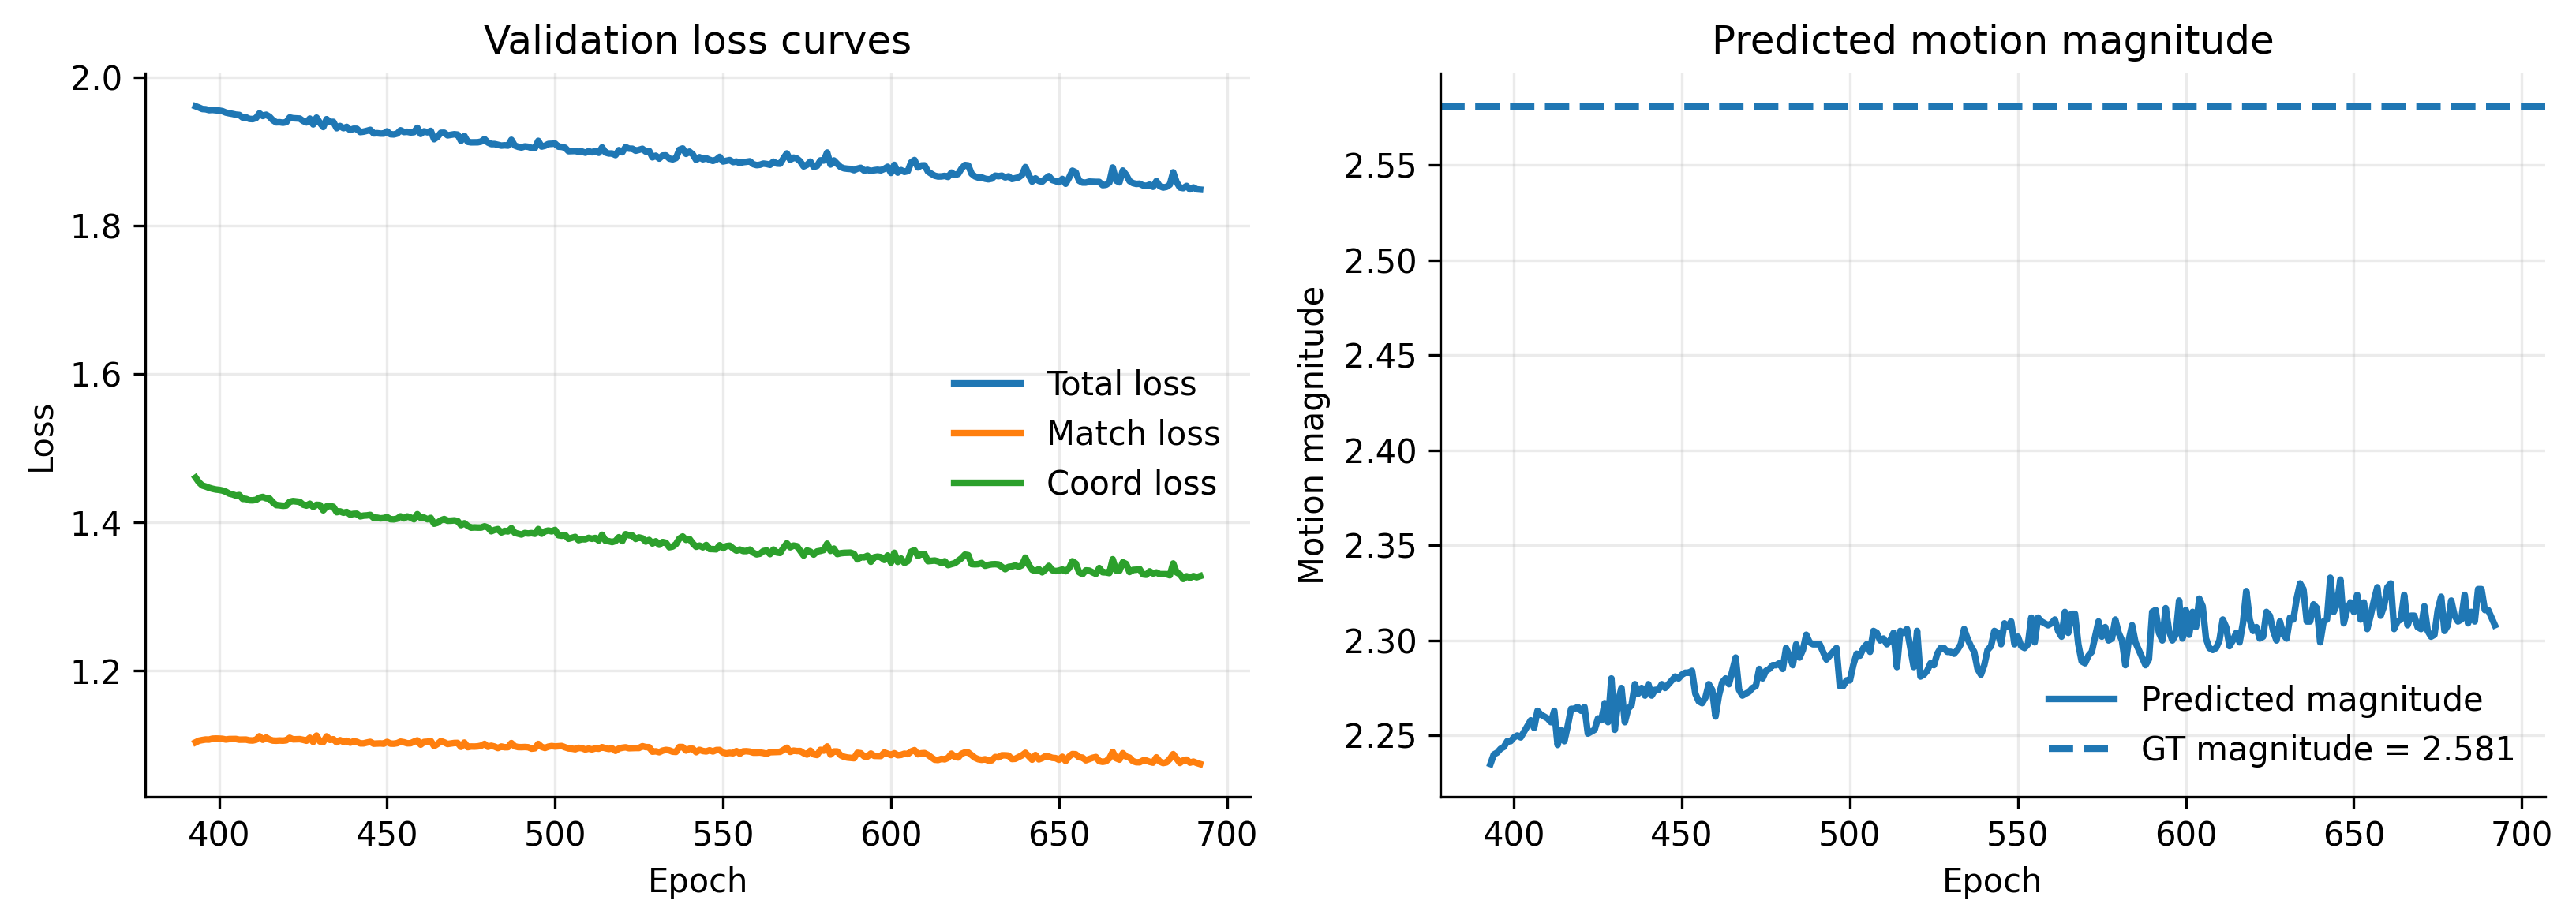

In [4]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


def parse_val_log(log_path):
    """
    Parse validation metrics from training log.

    Expected line example:
    [Val Epoch 001] loss=5.9870 | match=4.1899 | coord=4.6858 | pred_mag=1.753 | gt_mag=2.581
    """
    log_path = Path(log_path)

    val_line_pattern = re.compile(r"\[Val Epoch\s+(\d+)\](.*)")
    kv_pattern = re.compile(
        r"([A-Za-z_][A-Za-z0-9_]*)=([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)"
    )

    rows = []

    with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = val_line_pattern.search(line)
            if m is None:
                continue

            epoch = int(m.group(1))
            metric_text = m.group(2)

            row = {"epoch": epoch}
            for key, value in kv_pattern.findall(metric_text):
                row[key] = float(value)

            rows.append(row)

    if len(rows) == 0:
        raise RuntimeError(
            f"No validation lines found in log file: {log_path}\n"
            "Please check whether the log contains lines like '[Val Epoch xxx]'."
        )

    df = pd.DataFrame(rows)
    df = df.sort_values("epoch")
    df = df.drop_duplicates(subset="epoch", keep="last").reset_index(drop=True)

    required_cols = ["epoch", "loss", "match", "coord", "pred_mag", "gt_mag"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise RuntimeError(
            f"Missing columns in parsed validation log: {missing}\n"
            f"Available columns are: {list(df.columns)}"
        )

    return df


def plot_loss_and_mag(
    log_path,
    save_path="training_curves.pdf",
    save_csv=True,
):
    log_path = Path(log_path)
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)

    df = parse_val_log(log_path)

    if save_csv:
        csv_path = save_path.with_suffix(".csv")
        df.to_csv(csv_path, index=False)
        print(f"Saved parsed metrics to: {csv_path}")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=300)

    # -------------------------
    # Panel 1: loss curves
    # -------------------------
    ax = axes[0]

    ax.plot(
        df["epoch"],
        df["loss"],
        linewidth=2.0,
        label="Total loss",
    )
    ax.plot(
        df["epoch"],
        df["match"],
        linewidth=2.0,
        label="Match loss",
    )
    ax.plot(
        df["epoch"],
        df["coord"],
        linewidth=2.0,
        label="Coord loss",
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Validation loss curves")
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.25)

    # -------------------------
    # Panel 2: pred_mag vs gt_mag
    # -------------------------
    ax = axes[1]

    ax.plot(
        df["epoch"],
        df["pred_mag"],
        linewidth=2.0,
        label="Predicted magnitude",
    )

    # If gt_mag is constant, draw a horizontal dashed line.
    gt_values = df["gt_mag"].dropna().unique()
    if len(gt_values) == 1:
        gt_mag = gt_values[0]
        ax.axhline(
            gt_mag,
            linestyle="--",
            linewidth=2.0,
            label=f"GT magnitude = {gt_mag:.3f}",
        )
    else:
        ax.plot(
            df["epoch"],
            df["gt_mag"],
            linestyle="--",
            linewidth=2.0,
            label="GT magnitude",
        )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Motion magnitude")
    ax.set_title("Predicted motion magnitude")
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.25)

    for ax in axes:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    fig.savefig(save_path, bbox_inches="tight")
    print(f"Saved figure to: {save_path}")

    # Also save PNG for quick preview.
    png_path = save_path.with_suffix(".png")
    fig.savefig(png_path, bbox_inches="tight")
    print(f"Saved figure to: {png_path}")

    plt.show()

    return df


if __name__ == "__main__":
    log_path = r"/home/zhangqinghua/CoarseFlow/checkpoints/coarseflow_v7_stage2_K5_sharpen/train.log"

    plot_loss_and_mag(
        log_path=log_path,
        save_path="training_curves/loss_and_magnitude_curves.pdf",
        save_csv=True,
    )

In [11]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
PROJECT_ROOT = Path("/home/zhangqinghua/CoarseFlow").resolve()
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
from training import inference

PROJECT_ROOT: /home/zhangqinghua/CoarseFlow


/home/zhangqinghua/.conda/envs/coarseflow_npu/lib/python3.10/site-packages/torch_npu/contrib/transfer_to_npu.py:347: ImportWarning: 
    *************************************************************************************************************
    The torch.Tensor.cuda and torch.nn.Module.cuda are replaced with torch.Tensor.npu and torch.nn.Module.npu now..
    The torch.cuda.DoubleTensor is replaced with torch.npu.FloatTensor cause the double type is not supported now..
    The backend in torch.distributed.init_process_group set to hccl now..
    The torch.cuda.* and torch.cuda.amp.* are replaced with torch.npu.* and torch.npu.amp.* now..
    The device parameters have been replaced with npu in the function below:
    torch.logspace, torch.randint, torch.hann_window, torch.rand, torch.full_like, torch.ones_like, torch.rand_like, torch.randperm, torch.arange, torch.frombuffer, torch.normal, torch._empty_per_channel_affine_quantized, torch.empty_strided, torch.empty_like, torch.scala

In [63]:
import json
from datasets import synthetic_dataset
pth_path = "/home/zhangqinghua/CoarseFlow/checkpoints/coarseflow_v7_stage4_spatial_residual/best.pth"
pth_before = "/home/zhangqinghua/CoarseFlow/scripys/checkpoints/coarseflow_v6_stage3b_iter3_sharpen/best.pth"

model_config = dict(
    # =====================================================
    # Core
    # =====================================================
    dim=96,
    radius=(4, 3, 3),
    temperature=0.05,
    use_learned_matching=True,
    matcher_mode="hybrid",

    control_stride=16,
    encoder_stride=8,

    num_refine_iters=1,
    query_chunk_size=256,

    # =====================================================
    # Moving encoder
    # =====================================================
    moving_base_channels=(24, 48, 96),
    moving_num_blocks=(2, 4, 4),
    moving_mlp_ratio=2.0,

    moving_window_attn_layers=6,
    moving_window_size=8,
    moving_attn_num_heads=4,
    moving_slice_fusion_blocks=1,

    # =====================================================
    # Reference encoder
    # =====================================================
    ref_base_channels=(24, 48, 96),
    ref_num_blocks=(2, 4, 4),
    ref_refine_blocks=1,
    ref_mlp_ratio=2.0,

    ref_attn_layers=6,
    ref_attn_num_heads=4,
    ref_attn_window_size=(4, 8, 8),
    ref_attn_mlp_ratio=2.0,

    # =====================================================
    # Embeddings
    # =====================================================
    use_coord_embed=True,
    use_spacing_embed=True,

    # =====================================================
    # Matcher
    # =====================================================
    use_offset_encoding=True,
    use_offset_bias=True,
    use_local_cross_attn=True,
    local_attn_temperature=0.20,
    matcher_cross_attn_layers=3,
    matcher_cross_attn_heads=4,
    matcher_ffn_ratio=2.0,
    matcher_attn_drop=0.0,
    matcher_proj_drop=0.0,
    matcher_init_gamma=1e-2,

    # =====================================================
    # Spatial coordinate residual refinement: ON for Stage 4
    # =====================================================
    # Keep num_refine_iters=1 above. This avoids the memory increase
    # from running the full local matcher 2-3 times. The residual head
    # learns a small continuous correction after the /8 coarse match.
    use_coord_residual=True,
    residual_type="spatial",

    # 128 hidden dim + 3 blocks is deliberately lighter than the
    # previous 256 dim + 5 blocks setting, and is safer for inference.
    residual_hidden_dim=128,
    residual_num_blocks=3,

    # V6 matches on /8 XY features, so allow several raw-pixel XY
    # correction pixels to compensate for coarse-grid quantization.
    residual_max_delta=(2.0, 8.0, 8.0),

    residual_use_disp=True,

    # False uses kernel=(1,3,3) inside the spatial residual head.
    # This reduces memory/compute compared with full 3D residual convs.
    residual_use_3d=False,

    # Detach coarse outputs/features so the residual stage behaves like
    # a lightweight calibrator on top of the trained coarse V6 model.
    residual_detach_coarse=True,
    residual_detach_features=True,
)

  


# train.ipynb - Cell 4
model_config_attn = dict(
    dim=96,
    radius=(4, 5, 5),
    temperature=0.05,
    use_learned_matching=True,
    matcher_mode="hybrid",

    control_stride=16,
    encoder_stride=4,
    num_refine_iters=1,
    query_chunk_size=128,

    moving_num_convnext_blocks=3,
    moving_window_attn_layers=2,

    # reference attention
    ref_use_attention=True,
    ref_attn_layers=2,
    ref_attn_num_heads=4,
    ref_attn_window_size=(3, 8, 8),
    ref_attn_mlp_ratio=2.0,
    ref_base_channels=(32, 64, 96),
    ref_num_blocks=(2, 4, 4),
    ref_refine_blocks=3,
    use_coord_embed=True,

    use_offset_encoding=True,
    use_offset_bias=True,
    use_local_cross_attn=True,
    local_attn_temperature=0.20,

    use_spacing_embed=True,
)
model_config_attn.update(
    dict(
        # moving attention
        moving_window_attn_layers=2,

        # reference attention
        ref_use_attention=True,
        ref_attn_layers=2,
        ref_attn_num_heads=4,
        ref_attn_window_size=(3, 8, 8),
        ref_attn_mlp_ratio=2.0,
        num_refine_iters=1,

    )
)

model_config_before = dict(model_config_attn)
cfg = inference.CoarseFlowInferenceConfig(
    pth_path=pth_path,
    model_config=model_config,
    model_module="models.SparseGMFlow3D_v2",   # 按你的实际文件名改
    model_class="CoarseMatchingNetV6",
    device="cuda:2",                           # NPU 环境可改成对应 device
    strict_load=True,
    use_amp=False,
)
cfg_before = inference.CoarseFlowInferenceConfig(
    pth_path=pth_before,
    model_config=model_config_before,
    model_module="models.SparseGMFlow3D",   # 按你的实际文件名改
    model_class="CoarseMatchingNetV5",
    device="cuda:2",                           # NPU 环境可改成对应 device
    strict_load=True,
    use_amp=False,
)
manifest_summary_path =  "/home/zhangqinghua/CoarseFlow/cached_datasets/coarseflow_v6/manifest_summary.json"

with open(manifest_summary_path, "r") as f:
    manifest_summary = json.load(f)

predictor = inference.CoarseFlowPredictor(cfg)

val_loader_stage1, _, _ = synthetic_dataset.build_sameShape_loader(
    manifest_summary["stage1_val"],
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    drop_last=False,
    verbose=True,
    distributed=False,
)

va2_loader_stage2, _, _ = synthetic_dataset.build_sameShape_loader(
    manifest_summary["stage2_val"],
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    drop_last=False,
    verbose=True,
    distributed=False,
)
val_loader_stage3, _, _ = synthetic_dataset.build_sameShape_loader(
    manifest_summary["stage3_val"],
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    drop_last=False,
    verbose=True,
    distributed=False,
)

print("Loaded model.")
print("Load message:", predictor.load_msg)

[SameShapeBatchSampler] groups:
  key=(K,D,H,W)=(5, 20, 256, 256), n=71
  key=(K,D,H,W)=(5, 30, 256, 256), n=19
[SameShapeBatchSampler] groups:
  key=(K,D,H,W)=(3, 20, 256, 256), n=51
  key=(K,D,H,W)=(3, 30, 256, 256), n=21
  key=(K,D,H,W)=(5, 20, 256, 256), n=60
  key=(K,D,H,W)=(5, 30, 256, 256), n=12
  key=(K,D,H,W)=(7, 20, 256, 256), n=62
  key=(K,D,H,W)=(7, 30, 256, 256), n=10
[SameShapeBatchSampler] groups:
  key=(K,D,H,W)=(3, 20, 256, 256), n=39
  key=(K,D,H,W)=(3, 30, 256, 256), n=9
  key=(K,D,H,W)=(5, 20, 256, 256), n=38
  key=(K,D,H,W)=(5, 30, 256, 256), n=10
  key=(K,D,H,W)=(7, 20, 256, 256), n=37
  key=(K,D,H,W)=(7, 30, 256, 256), n=11
Loaded model.
Load message: <All keys matched successfully>


In [64]:
from importlib import reload
reload(inference)
def evaluate_val_loader_with_predictor(
    predictor,
    loader,
    dataset_name,
    normalize=True,
    use_patchwise=False,
    patchwise_kwargs=None,
    max_batches=None,
):
    rows = []

    for batch_idx, batch in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        mov_b = batch["mov"]
        ref_b = batch["ref"]

        z_init_b = batch.get("z_init", None)
        if z_init_b is None:
            z_init_b = batch.get("sparse_z_idx", None)

        spacing_b = batch.get("spacing", None)

        B = mov_b.shape[0]

        for b in range(B):
            mov_zyx = mov_b[b, 0].detach().cpu().numpy()
            ref_zyx = ref_b[b, 0].detach().cpu().numpy()
            z_init = z_init_b[b].detach().cpu().numpy()

            if spacing_b is not None:
                ref_spacing = spacing_b[b].detach().cpu().numpy().tolist()
            else:
                ref_spacing = (1.0, 1.0, 1.0)

            # ------------------------------------------------
            # First run prediction once. To extract GT coords,
            # we need pred control-grid shape, so GT extraction
            # is handled inside a small pre-call below.
            # ------------------------------------------------
            # Easier way:
            # call evaluate_one_sample first without gt_coords,
            # but that would duplicate inference if we then need shape.
            #
            # Better way:
            # use gt_coords directly if it exists.
            # ------------------------------------------------

            # If gt_coords exists directly, use it.
            # If only gt_disp exists, we need pred shape. In most training batches,
            # gt_disp has the same control-grid shape, so we can reconstruct directly.
            gt_coords_ctrl = None
            valid_mask_ctrl = None

            if "gt_coords" in batch:
                gt_coords_ctrl = (
                    batch["gt_coords"][b]
                    .detach()
                    .cpu()
                    .numpy()
                    .astype(np.float32)
                )

            elif "gt_coords_ctrl" in batch:
                gt_coords_ctrl = (
                    batch["gt_coords_ctrl"][b]
                    .detach()
                    .cpu()
                    .numpy()
                    .astype(np.float32)
                )

            if "valid_mask" in batch:
                valid_mask_ctrl = (
                    batch["valid_mask"][b]
                    .detach()
                    .cpu()
                    .numpy()
                    .astype(bool)
                )

            elif "valid" in batch:
                valid_mask_ctrl = (
                    batch["valid"][b]
                    .detach()
                    .cpu()
                    .numpy()
                    .astype(bool)
                )

            out = inference.evaluate_one_sample_with_predictor(
                predictor=predictor,
                mov_zyx=mov_zyx,
                ref_zyx=ref_zyx,
                z_init=z_init,
                ref_spacing=ref_spacing,
                normalize=normalize,
                phase_order="xyz",
                use_patchwise=use_patchwise,
                patchwise_kwargs=patchwise_kwargs,
                gt_coords_ctrl_zyx=gt_coords_ctrl,
                valid_mask_ctrl=valid_mask_ctrl,
            )

            # 如果 batch 里没有 gt_coords，但有 gt_disp，
            # 这里补算一次 coord metrics。
            if ("coord_l2_pred" not in out) and ("gt_disp" in batch):
                pred_phase_dummy = None

                # 这种情况下需要 pred_coords_ctrl_zyx。
                # evaluate_one_sample_with_predictor 里面没有返回它，
                # 所以建议你在上面 result 里额外保存 pred_coords_ctrl_zyx。
                pass

            row = {
                "dataset": dataset_name,
                "batch_index": batch_idx,
                "sample_in_batch": b,

                # image-level metrics
                "mse_init": out["mse_init"],
                "mse_pred": out["mse_pred"],
                "delta_mse": out["delta_mse"],
                "relative_mse_improvement": out["relative_mse_improvement"],
                "mse_ratio_pred_over_init": out["mse_ratio_pred_over_init"],
            }

            # Add coordinate metrics if available.
            for key in [
                "coord_l1_init",
                "coord_l1_pred",
                "coord_l2_init",
                "coord_l2_pred",
                "z_abs_init",
                "z_abs_pred",
                "xy_l2_init",
                "xy_l2_pred",
                "coord_l1_improvement",
                "coord_l2_improvement",
                "z_abs_improvement",
                "xy_l2_improvement",
                "coord_l1_relative_improvement",
                "coord_l2_relative_improvement",
                "xy_l2_relative_improvement",
            ]:
                if key in out:
                    row[key] = out[key]

            rows.append(row)

        if batch_idx % 10 == 0:
            df_tmp = pd.DataFrame(rows)

            msg = (
                f"[{dataset_name}] batch {batch_idx:04d} | "
                f"rel_mse_imp={df_tmp['relative_mse_improvement'].mean():.4f} | "
                f"mse_ratio={df_tmp['mse_ratio_pred_over_init'].mean():.4f}"
            )

            if "coord_l2_pred" in df_tmp.columns:
                msg += (
                    f" | coord_l2_pred={df_tmp['coord_l2_pred'].mean():.4f}"
                    f" | coord_l2_imp={df_tmp['coord_l2_improvement'].mean():.4f}"
                )

            print(msg)

    return pd.DataFrame(rows)

def plot_violin(
    df,
    col="delta_mse",
    ylabel=None,
    title=None,
    dataset_col="dataset",
    dataset_order=None,
    colors=None,
    figsize=(5.8, 4.2),
    alpha=0.45,
    show_points=True,
    point_alpha=0.45,
    point_size=18,
    jitter=0.06,
    show_mean=True,
    show_median=True,
    show_n=True,
    ylim=None,
    save_path=None,
    dpi=300,
):
    import numpy as np
    import matplotlib.pyplot as plt

    # ------------------------------------------------------------
    # Prepare data
    # ------------------------------------------------------------
    if dataset_order is None:
        names = list(df[dataset_col].dropna().unique())
    else:
        names = list(dataset_order)

    data = []
    for name in names:
        vals = df.loc[df[dataset_col] == name, col].dropna().values.astype(float)
        data.append(vals)

    if ylabel is None:
        ylabel = col
    if title is None:
        title = col

    # Nature-like muted palette
    if colors is None:
        colors = [
            "#4C72B0",  # blue
            "#DD8452",  # orange
            "#55A868",  # green
            "#C44E52",  # red
            "#8172B2",  # purple
            "#937860",  # brown
        ]

    colors = [colors[i % len(colors)] for i in range(len(names))]

    # ------------------------------------------------------------
    # Figure style
    # ------------------------------------------------------------
    plt.rcParams.update({
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "axes.linewidth": 1.0,
    })

    fig, ax = plt.subplots(figsize=figsize)

    # ------------------------------------------------------------
    # Violin plot
    # ------------------------------------------------------------
    positions = np.arange(1, len(names) + 1)

    parts = ax.violinplot(
        data,
        positions=positions,
        widths=0.72,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )

    for i, body in enumerate(parts["bodies"]):
        body.set_facecolor(colors[i])
        body.set_edgecolor(colors[i])
        body.set_alpha(alpha)
        body.set_linewidth(1.2)

    # ------------------------------------------------------------
    # Scatter points
    # ------------------------------------------------------------
    rng = np.random.default_rng(123)

    if show_points:
        for i, vals in enumerate(data):
            if len(vals) == 0:
                continue

            x = rng.normal(
                loc=positions[i],
                scale=jitter,
                size=len(vals),
            )

            ax.scatter(
                x,
                vals,
                s=point_size,
                color=colors[i],
                alpha=point_alpha,
                edgecolor="white",
                linewidth=0.35,
                zorder=3,
            )

    # ------------------------------------------------------------
    # Mean / median markers
    # ------------------------------------------------------------
    for i, vals in enumerate(data):
        if len(vals) == 0:
            continue

        x = positions[i]
        median = np.median(vals)
        mean = np.mean(vals)

        if show_median:
            ax.plot(
                [x - 0.22, x + 0.22],
                [median, median],
                color="black",
                linewidth=2.0,
                solid_capstyle="round",
                zorder=5,
            )

        if show_mean:
            ax.scatter(
                x,
                mean,
                s=38,
                color="white",
                edgecolor="black",
                linewidth=1.1,
                zorder=6,
            )

        if show_n:
            y_min, y_max = np.nanmin(vals), np.nanmax(vals)
            y_text = y_max + 0.04 * (y_max - y_min + 1e-8)

            ax.text(
                x,
                y_text,
                f"n={len(vals)}",
                ha="center",
                va="bottom",
                fontsize=9,
                color="black",
            )

    # ------------------------------------------------------------
    # Reference line
    # ------------------------------------------------------------
    ax.axhline(
        0.0,
        linestyle="--",
        linewidth=1.0,
        color="0.35",
        alpha=0.8,
        zorder=1,
    )

    # ------------------------------------------------------------
    # Axes
    # ------------------------------------------------------------
    ax.set_xticks(positions)
    ax.set_xticklabels(names, rotation=25, ha="right")

    ax.set_ylabel(ylabel)
    ax.set_title(title, pad=10)

    if ylim is not None:
        ax.set_ylim(ylim)

    ax.grid(axis="y", linestyle="-", linewidth=0.5, alpha=0.25)
    ax.grid(axis="x", visible=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="both", length=4, width=1.0)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        if str(save_path).lower().endswith(".png"):
            fig.savefig(str(save_path).replace(".png", ".pdf"), bbox_inches="tight")

    plt.show()

    return fig, ax

In [65]:
debug_dfs = []
val_loaders = {
    "stage1_val": val_loader_stage1,
    "stage2_val": va2_loader_stage2,
    "stage3_val": val_loader_stage3,
}

for name, loader in val_loaders.items():
    print("Debug:", name)

    df_one = evaluate_val_loader_with_predictor(
        predictor=predictor,
        loader=loader,
        dataset_name=name,
        normalize=True,
        use_patchwise=False,
        max_batches=100,
    )

    debug_dfs.append(df_one)

df_debug = pd.concat(debug_dfs, ignore_index=True)
df_debug

Debug: stage1_val
[stage1_val] batch 0000 | rel_mse_imp=0.8582 | mse_ratio=0.1418 | coord_l2_pred=0.7740 | coord_l2_imp=1.9846
[stage1_val] batch 0010 | rel_mse_imp=0.7191 | mse_ratio=0.2809 | coord_l2_pred=0.9689 | coord_l2_imp=1.0534
[stage1_val] batch 0020 | rel_mse_imp=0.7457 | mse_ratio=0.2543 | coord_l2_pred=1.0445 | coord_l2_imp=1.5126
[stage1_val] batch 0030 | rel_mse_imp=0.7461 | mse_ratio=0.2539 | coord_l2_pred=1.0278 | coord_l2_imp=1.6140
[stage1_val] batch 0040 | rel_mse_imp=0.7389 | mse_ratio=0.2611 | coord_l2_pred=0.9326 | coord_l2_imp=1.5004
[stage1_val] batch 0050 | rel_mse_imp=0.7452 | mse_ratio=0.2548 | coord_l2_pred=0.9194 | coord_l2_imp=1.5223
[stage1_val] batch 0060 | rel_mse_imp=0.7500 | mse_ratio=0.2500 | coord_l2_pred=0.8923 | coord_l2_imp=1.5374
[stage1_val] batch 0070 | rel_mse_imp=0.7523 | mse_ratio=0.2477 | coord_l2_pred=0.8817 | coord_l2_imp=1.5633
[stage1_val] batch 0080 | rel_mse_imp=0.7613 | mse_ratio=0.2387 | coord_l2_pred=0.8767 | coord_l2_imp=1.6602
D

,dataset,batch_index,sample_in_batch,mse_init,mse_pred,delta_mse,relative_mse_improvement,mse_ratio_pred_over_init,coord_l1_init,coord_l1_pred,...,z_abs_pred,xy_l2_init,xy_l2_pred,coord_l1_improvement,coord_l2_improvement,z_abs_improvement,xy_l2_improvement,coord_l1_relative_improvement,coord_l2_relative_improvement,xy_l2_relative_improvement
0,stage1_val,0,0,0.007709,0.001093,0.006616,0.858177,0.141821,4.452838,1.159431,...,0.382197,2.174568,0.605182,3.293407,1.984614,1.201850,1.569386,0.739620,0.719434,0.721700
1,stage1_val,1,0,0.003769,0.001018,0.002751,0.729850,0.270147,2.323272,2.063073,...,0.238576,1.325366,1.424445,0.260199,0.049828,0.379999,-0.099079,0.111997,0.032718,-0.074756
2,stage1_val,2,0,0.017068,0.003900,0.013168,0.771502,0.228497,4.872281,1.168742,...,0.270681,3.190883,0.710739,3.703539,2.681988,0.799818,2.480145,0.760124,0.771864,0.777260
3,stage1_val,3,0,0.005402,0.000944,0.004458,0.825205,0.174793,2.612429,0.958951,...,0.252010,1.761006,0.555008,1.653479,1.222508,0.157125,1.205998,0.632928,0.655266,0.684834
4,stage1_val,4,0,0.011128,0.000903,0.010225,0.918851,0.081148,7.354357,2.046378,...,0.463751,4.297314,1.242159,5.307979,3.265535,1.112729,3.055155,0.721746,0.703857,0.710945
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
285,stage3_val,95,0,0.006514,0.002392,0.004121,0.632729,0.367270,6.295664,2.512516,...,0.536488,4.115052,1.517457,3.783148,2.709250,0.592801,2.597595,0.600913,0.612311,0.631242
286,stage3_val,96,0,0.025034,0.006708,0.018326,0.732048,0.267952,8.151464,2.668292,...,0.605313,5.415891,1.669688,5.483173,3.868494,0.922621,3.746203,0.672661,0.674220,0.691706
287,stage3_val,97,0,0.022597,0.008004,0.014593,0.645801,0.354198,5.992651,1.709504,...,0.307875,3.804106,1.087532,4.283147,2.927815,0.892717,2.716574,0.714733,0.712971,0.714116
288,stage3_val,98,0,0.024135,0.005090,0.019045,0.789092,0.210907,6.565753,2.609379,...,0.536955,4.106087,1.656122,3.956375,2.649959,0.864665,2.449965,0.602577,0.590604,0.596667


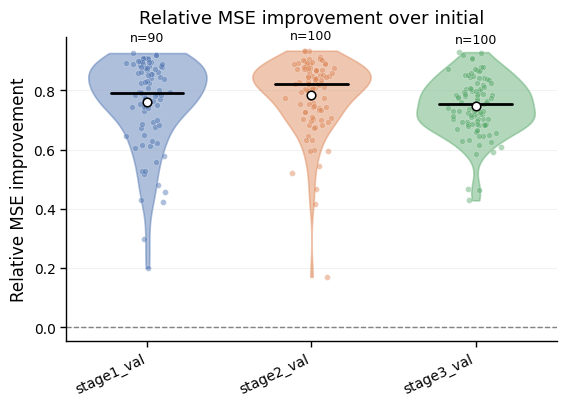

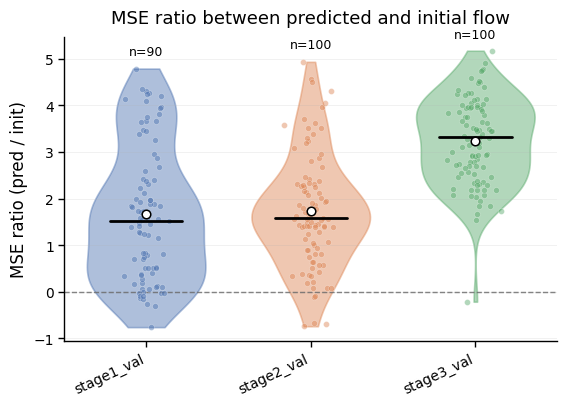

(<Figure size 580x420 with 1 Axes>,
 <Axes: title={'center': 'MSE ratio between predicted and initial flow'}, ylabel='MSE ratio (pred / init)'>)

In [67]:
plot_violin(df_debug, col="relative_mse_improvement", ylabel="Relative MSE improvement", title="Relative MSE improvement over initial")
plot_violin(df_debug, col="coord_l2_improvement", ylabel="MSE ratio (pred / init)", title="MSE ratio between predicted and initial flow")